
<br><br><br>
<p align="center">
  <img src="https://www.daiict.ac.in/sites/default/files/inline-images/20250107DAUfinalIDcol_SK-01_0.png" width="420"/>
</p>

<br><br><br>
<div align="center"> $\huge \textbf{Short Duration Debt Funds}$</div>
<br><br>

<p align="center">  $\Huge \textbf{Group 3}$</p>
<br><br>
<style>
  table, th, td {
    background-color: transparent !important;
  }
</style>
<div align="center" >
  <table >
    <tr>
      <td align="center" style="background-color:transparent; padding: 10px;">
        <img src="https://i.postimg.cc/wjV3cGR8/Passport-Photo.jpg" width="200"><br><br>
        <strong>Bavadiua Pranavkumar Dineshbhai</strong><br><br>
        <span>ID-202301458 </span><br><br>
      </td>
      <td align="center" style="background-color:transparent; padding: 10px;">
        <img src="https://i.postimg.cc/pXWRLSmV/OM-PATEL-PHOTO.jpg" width="200"><br><br>
        <strong>Patel Om</strong><br><br>
        <span>ID-202301027</span><br><br>
      </td>
      <td align="center" style="background-color:transparent; padding: 10px;">
        <img src="https://i.postimg.cc/JhxCcm6y/passportsizephoto.jpg"  width="200"><br><br>
        <strong> Chirage Katkoriya</strong> <br><br>
        <span>ID-202301259</span><br><br>
      </td>
    </tr>
  </table>
</div>
<br><br><br><br><br>


<p align="center" >  $\huge \textbf{IT462: Exploratory Data Analysis}$</p>

<br>

<p align="center">  $\huge \textbf{Autumn 2025}$ </p>

<br><br><br><br>

<p align="center" > $\large \textbf{Instructor: Dr. Gopinath Panda}$ </p>




<br><br><br><br><br><br>
<p align="center"> $ \textbf{© 2025 Dhirubhai Ambani University}$</p>
<br><br><br><br><br><br>

# **Import Libraries/Models**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn import tree
import datetime as dt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage
from sklearn.preprocessing import StandardScaler


# **Dataset**

In [2]:
url = "https://raw.githubusercontent.com/Om1505/EDA_Dataset_03/main/Dataset/EDA_Project_Dataset-5.xlsx"


# **Dataset Extraction**

In [3]:
schemes = pd.read_excel(url, engine='openpyxl', sheet_name=0)

In [4]:
main_funds = pd.read_excel(url, engine='openpyxl', sheet_name=4)

In [5]:
axis_data = pd.read_excel(url, engine='openpyxl', sheet_name=1)

In [6]:
hdfc_data = pd.read_excel(url, engine='openpyxl', sheet_name=2)

In [7]:
sbi_data = pd.read_excel(url, engine='openpyxl', sheet_name=3)

# **Dataset Information and Sample**

In [8]:
display(schemes.sample(5))
print("\n" * 2)
schemes.info()
print("\n" * 2)
schemes.describe()

,Scheme NAV Name,Net Asset Value,Date,Rating,Riskometer,Launch Date
239,UTI Short Duration Fund - Direct Plan - Monthl...,10.7459,2025-11-07,3.0,Moderate,NaN
214,Sundaram Short Duration Fund - (Formerly Known...,49.0933,2025-11-07,3.0,Moderate,NaN
172,LIC MF Short Duration Fund-Regular Plan-Monthl...,14.8943,2025-11-07,3.0,Moderate,NaN
4,Aditya Birla Sun Life Short Term Fund - REGULA...,10.4709,2025-11-07,4.0,Moderate,NaN
246,UTI Short Duration Fund - Regular Plan - Half-...,13.9027,2025-11-07,3.0,Moderate,NaN





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Scheme NAV Name  249 non-null    object        
 1   Net Asset Value  249 non-null    float64       
 2   Date             249 non-null    datetime64[ns]
 3   Rating           207 non-null    float64       
 4   Riskometer       249 non-null    object        
 5   Launch Date      26 non-null     object        
dtypes: datetime64[ns](1), float64(2), object(3)
memory usage: 11.8+ KB





,Net Asset Value,Date,Rating
count,249.000000,249,207.000000
mean,478.749312,2024-10-26 17:03:36.867469824,2.922705
min,0.000000,2015-06-08 00:00:00,1.000000
25%,11.324300,2025-06-27 00:00:00,2.000000
50%,15.108500,2025-11-07 00:00:00,3.000000
75%,33.928400,2025-11-07 00:00:00,4.000000
max,15097.536000,2025-11-07 00:00:00,5.000000
std,1750.017810,NaN,1.094477


In [9]:
display(main_funds.sample(5))
print("\n" * 2)
main_funds.info()
print("\n" * 2)
main_funds.describe()

,Scheme Name,Plan,Category Name,Crisil Rating,AuM (Cr),YTM,1W,1M,3M,6M,YTD,1Y,2Y,3Y,5Y,10Y,Riskometer,Expense Ratio (%),Net Assets (Cr),Launch Date
10,HDFC Short Term Debt Fund - Direct Plan - Growth,Direct Plan,Short Duration Fund,2.0,17621.91,7.08,0.0017,0.0075,0.0146,0.0358,0.0747,0.0863,0.0869,0.0831,0.0665,0.0773,Moderate,0.40,17622.0,2013-01-01
14,JM Short Duration Fund - Direct Plan - Growth,Direct Plan,Short Duration Fund,4.0,84.67,6.72,0.0013,0.0056,0.0134,0.0333,0.0733,0.0842,0.0826,0.0781,NaN,NaN,Moderate,0.38,85.0,2022-08-29
11,HSBC Short Duration Fund - Direct Plan - Growth,Direct Plan,Short Duration Fund,3.0,4454.79,6.81,0.0014,0.0063,0.0137,0.0349,0.0753,0.0866,0.0851,0.0796,0.0608,0.0727,Moderate,0.27,4455.0,2013-01-01
18,Mirae Asset Short Duration Fund - Direct Plan ...,Direct Plan,Short Duration Fund,4.0,703.54,7.03,0.0014,0.0064,0.0137,0.0341,0.0762,0.0883,0.0873,0.0817,0.0644,NaN,Moderate,0.23,704.0,2018-03-16
23,TRUSTMF Short Duration Fund - Direct Plan - Gr...,Direct Plan,Short Duration Fund,4.0,102.44,6.67,0.0010,0.0055,0.0135,0.0341,0.0742,0.0850,0.0819,0.0783,NaN,NaN,Moderate,0.23,102.0,2021-08-06





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Scheme Name        26 non-null     object        
 1   Plan               26 non-null     object        
 2   Category Name      26 non-null     object        
 3   Crisil Rating      24 non-null     float64       
 4   AuM (Cr)           25 non-null     float64       
 5   YTM                25 non-null     float64       
 6   1W                 25 non-null     float64       
 7   1M                 25 non-null     float64       
 8   3M                 25 non-null     float64       
 9   6M                 25 non-null     float64       
 10  YTD                24 non-null     float64       
 11  1Y                 24 non-null     float64       
 12  2Y                 24 non-null     float64       
 13  3Y                 23 non-null     float64       
 14  5Y       

,Crisil Rating,AuM (Cr),YTM,1W,1M,3M,6M,YTD,1Y,2Y,3Y,5Y,10Y,Expense Ratio (%),Net Assets (Cr),Launch Date
count,24.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,24.000000,24.000000,24.00000,23.000000,20.000000,18.000000,25.000000,25.000000,25
mean,2.958333,5412.504400,6.868000,0.001380,0.006160,0.013452,0.034108,0.073808,0.085392,0.08575,0.081317,0.066780,0.073600,0.348400,5412.440000,2015-06-05 03:50:24
min,1.000000,71.330000,6.260000,0.000600,0.004500,0.010300,0.028600,0.066500,0.076400,0.07950,0.076300,0.059000,0.062300,0.200000,71.000000,2013-01-01 00:00:00
25%,2.000000,195.110000,6.730000,0.001300,0.005600,0.013000,0.033300,0.072600,0.084025,0.08485,0.080350,0.062050,0.070350,0.300000,195.000000,2013-01-01 00:00:00
50%,3.000000,925.170000,6.870000,0.001400,0.006300,0.013600,0.034100,0.074250,0.086100,0.08635,0.081500,0.064150,0.074050,0.350000,925.000000,2013-01-01 00:00:00
75%,4.000000,10673.190000,7.000000,0.001500,0.006700,0.014300,0.035500,0.075725,0.087175,0.08715,0.083000,0.067500,0.077375,0.380000,10673.000000,2018-03-16 00:00:00
max,5.000000,22387.340000,7.310000,0.001900,0.008000,0.015200,0.037300,0.078700,0.091800,0.09030,0.084900,0.106200,0.082200,0.520000,22387.000000,2025-01-31 00:00:00
std,1.082636,7028.063679,0.223737,0.000274,0.000834,0.001218,0.002076,0.002956,0.003497,0.00272,0.002152,0.010116,0.005355,0.072266,7028.129683,NaN


In [10]:
display(sbi_data.sample(5))
print("\n" * 2)
sbi_data.info()
print("\n" * 2)
sbi_data.describe()

,Date,NAV,Change,Change(%)
963,2021-11-09,26.8654,0.01,0.0004
145,2025-04-04,33.4753,0.02,0.0006
928,2021-12-29,26.9288,0.01,0.0002
722,2022-11-04,27.6619,0.01,0.0002
518,2023-09-21,29.5347,0.01,0.0002





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1186 entries, 0 to 1185
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1186 non-null   datetime64[ns]
 1   NAV        1186 non-null   float64       
 2   Change     1183 non-null   float64       
 3   Change(%)  1175 non-null   float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 37.2 KB





,Date,NAV,Change,Change(%)
count,1186,1186.000000,1183.000000,1175.000000
mean,2023-05-26 07:26:48.768971264,29.453570,0.007768,0.000259
min,2020-12-04 00:00:00,25.876400,-0.120000,-0.004400
25%,2022-02-24 06:00:00,27.073325,0.000000,0.000000
50%,2023-05-31 12:00:00,29.003150,0.010000,0.000200
75%,2024-08-25 06:00:00,31.696050,0.010000,0.000500
max,2025-11-07 00:00:00,35.038600,0.120000,0.003800
std,NaN,2.739042,0.015881,0.000528


In [11]:
display(axis_data.sample(5))
print("\n" * 2)
axis_data.info()
print("\n" * 2)
axis_data.describe()

,Net Asset Value,Date
163,34.1112,2025-08-08
31,32.2828,2025-01-24
181,34.1581,2025-09-04
142,33.9636,2025-07-10
186,34.2232,2025-09-12





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223 entries, 0 to 222
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Net Asset Value  223 non-null    float64       
 1   Date             223 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.6 KB





,Net Asset Value,Date
count,223.000000,223
mean,33.418824,2025-05-25 06:40:21.524663552
min,32.028500,2024-12-11 00:00:00
25%,32.515500,2025-03-03 12:00:00
50%,33.736300,2025-05-29 00:00:00
75%,34.103900,2025-08-13 12:00:00
max,34.668500,2025-11-07 00:00:00
std,0.836388,NaN


In [12]:
display(hdfc_data.sample(5))
print("\n" * 2)
hdfc_data.info()
print("\n" * 2)
hdfc_data.describe()

,Net Asset Value,Date
756,10.3163,2024-12-18
442,10.3199,2023-08-30
27,10.3161,2021-12-16
761,10.3204,2024-12-26
571,10.3073,2024-03-12





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 972 entries, 0 to 971
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Net Asset Value  972 non-null    float64       
 1   Date             972 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1)
memory usage: 15.3 KB





,Net Asset Value,Date
count,972.000000,972
mean,10.319963,2023-11-05 14:05:55.555555840
min,10.224800,2021-11-08 00:00:00
25%,10.309800,2022-11-06 06:00:00
50%,10.320200,2023-11-02 12:00:00
75%,10.331925,2024-11-06 06:00:00
max,10.423400,2025-11-07 00:00:00
std,0.021784,NaN


# **Data Preprocessing**

In [13]:
schemes['Launch Date'] = pd.to_datetime(schemes['Launch Date'], errors='coerce')
main_funds['Launch Date'] = pd.to_datetime(main_funds['Launch Date'], errors='coerce')

In [14]:
schemes['Scheme NAV Name'] = schemes['Scheme NAV Name'].apply(lambda x: x.strip())
main_funds['Scheme Name'] = main_funds['Scheme Name'].apply(lambda x: x.strip())

In [15]:
schemes['Fund Name'] = schemes['Scheme NAV Name'].astype(str).apply(lambda x: x.split("-")[0])
main_funds['Scheme Name'] = main_funds['Scheme Name'].astype(str).apply(lambda x: x.split("-")[0])
schemes['Fund Name'] = schemes['Fund Name'].apply(lambda x: x.strip())

In [16]:
main_funds.drop(columns=['Net Assets (Cr)'],inplace = True)
main_funds.drop(['Plan','Category Name'],axis=1,inplace=True)

In [17]:
columns = ['1W', '1M', '3M', '6M', 'YTD', '1Y', '2Y', '3Y', '5Y', '10Y', 'Expense Ratio (%)']
main_funds[columns] = main_funds[columns] * 100
display(main_funds.head())

,Scheme Name,Crisil Rating,AuM (Cr),YTM,1W,1M,3M,6M,YTD,1Y,2Y,3Y,5Y,10Y,Riskometer,Expense Ratio (%),Launch Date
0,Aditya Birla Sun Life Short Term Fund,1.0,10696.23,7.21,0.18,0.80,1.49,3.58,7.58,8.84,8.84,8.35,6.91,8.07,Moderate,37.0,2013-01-01
1,Axis Short Duration Fund,3.0,12200.82,7.00,0.15,0.69,1.51,3.73,7.87,9.18,8.94,8.39,6.70,7.86,Moderate,38.0,2013-01-01
2,Bandhan Bond Fund,5.0,10673.19,6.58,0.15,0.48,1.07,3.22,7.30,8.49,8.64,8.19,6.23,7.43,Moderate,34.0,2013-01-01
3,Bank of India Short Term Income Fund,2.0,241.11,6.73,0.13,0.57,1.43,3.36,6.93,8.02,9.03,8.10,10.62,6.23,Moderate,52.0,2013-01-01
4,Baroda BNP Paribas Short Duration Fund,2.0,271.94,6.96,0.12,0.63,1.33,3.46,7.54,8.70,8.64,8.30,6.52,7.71,Moderate,44.0,2013-01-01


# **Missing value Visualization**

<Axes: >

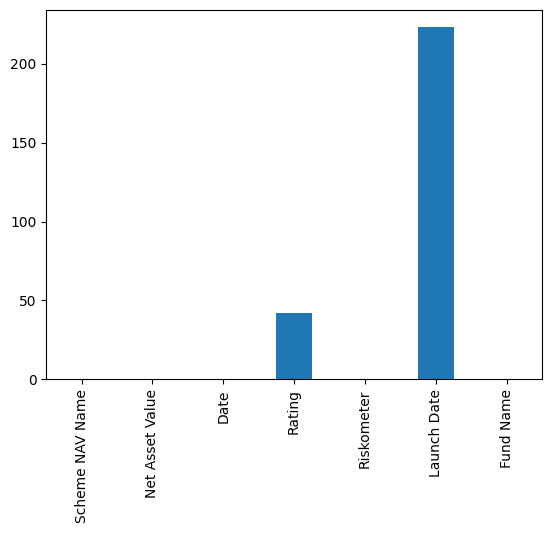

In [18]:
schemes.isnull().sum().plot(kind='bar')

<Axes: >

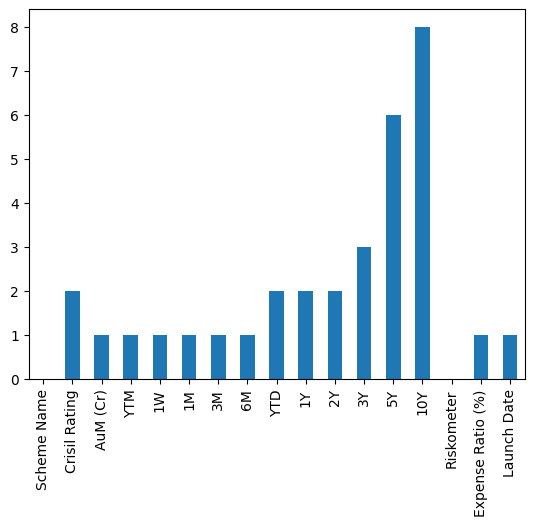

In [19]:
main_funds.isnull().sum().plot(kind='bar')

<Axes: >

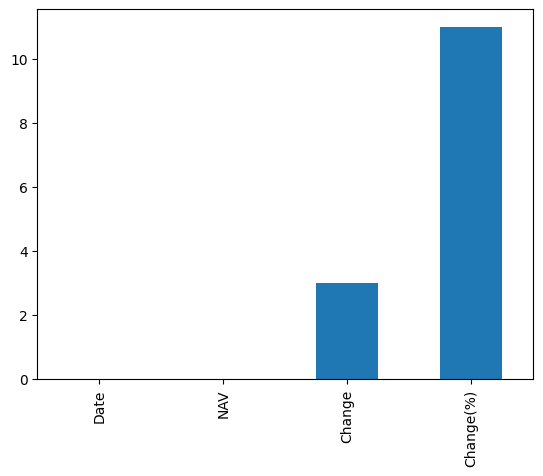

In [20]:
sbi_data.isnull().sum().plot(kind='bar')

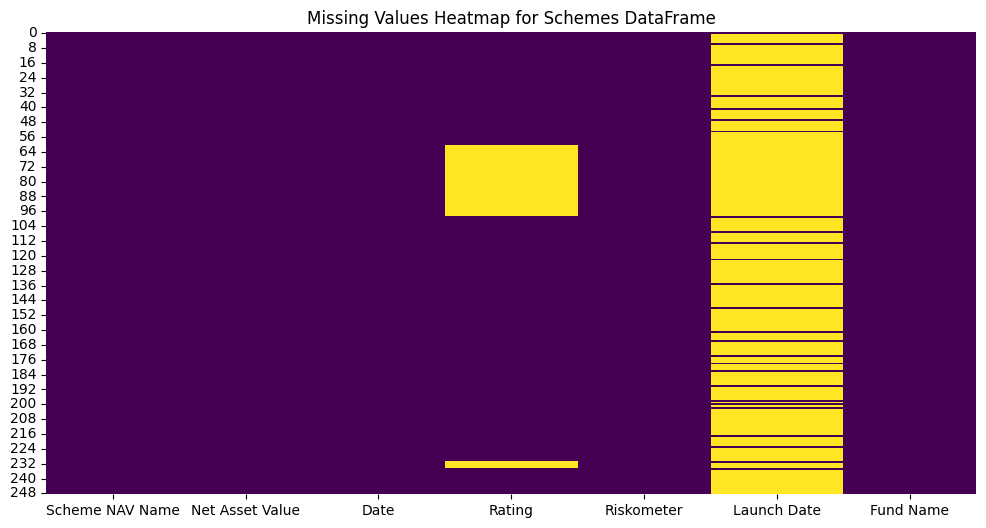

In [21]:
plt.figure(figsize=(12, 6))
sns.heatmap(schemes.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap for Schemes DataFrame')
plt.show()

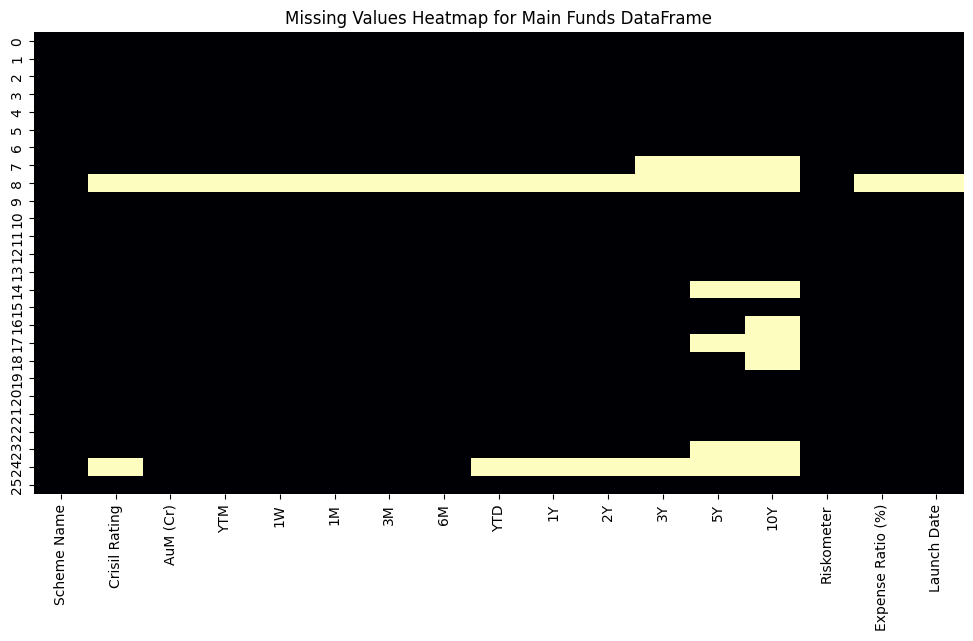

In [22]:
plt.figure(figsize=(12, 6))
sns.heatmap(main_funds.isnull(), cbar=False, cmap='magma')
plt.title('Missing Values Heatmap for Main Funds DataFrame')
plt.show()

# **Handling Missing Values**

In [23]:
main_funds.drop(index=8, inplace=True)

In [24]:
schemes['Launch Date']=schemes['Launch Date'].ffill()
main_funds['Launch Date']=main_funds['Launch Date'].ffill()

In [25]:
main_funds.loc[main_funds['Crisil Rating'].isnull(), 'Crisil Rating'] = np.ceil(main_funds['Crisil Rating'].mean())

In [26]:
main_funds.loc[main_funds['YTD'].isnull(), 'YTD'] = main_funds['YTD'].mean()

In [27]:
main_funds.loc[main_funds['1Y'].isnull(), '1Y'] = main_funds['1Y'].mean()

In [28]:
main_funds.loc[main_funds['2Y'].isnull(), '2Y'] = main_funds['2Y'].mean()

In [29]:
main_funds.loc[main_funds['3Y'].isnull(), '3Y'] = main_funds['3Y'].mean()

In [30]:
main_funds.loc[main_funds['5Y'].isnull(), '5Y'] = main_funds['5Y'].mean()

In [31]:
main_funds.loc[main_funds['10Y'].isnull(), '10Y'] = main_funds['10Y'].mean()

In [32]:
sbi_data.loc[sbi_data['Change'].isnull(), 'Change'] = sbi_data['Change'].mean()

In [33]:
sbi_data.loc[sbi_data['Change(%)'].isnull(), 'Change(%)'] = sbi_data['Change(%)'].mean()

In [34]:
schemes.loc[schemes['Rating'].isnull(), 'Rating'] = np.ceil(schemes['Rating'].mean())

# **Outliers Visualization and Handling**

**schemes - Net Asset Value**



<Axes: xlabel='Net Asset Value'>

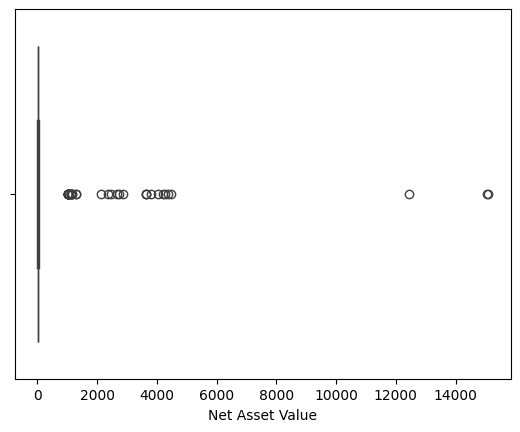

In [35]:
sns.boxplot(x=schemes['Net Asset Value'])

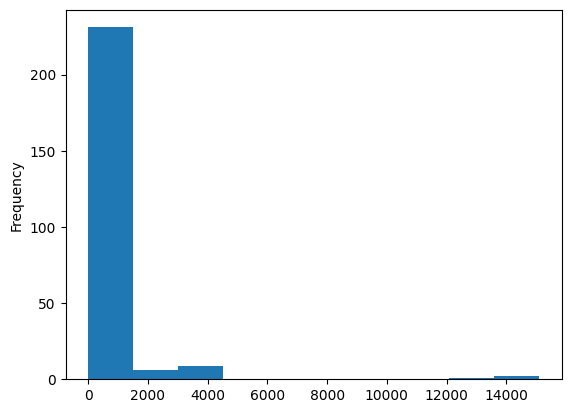

In [36]:
schemes['Net Asset Value'].plot(kind='hist')
plt.show()

In [37]:
schemes_copy = schemes.copy()

In [38]:
Q1 = schemes_copy['Net Asset Value'].quantile(0.25)
Q3 = schemes_copy['Net Asset Value'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

schemes_copy['Net Asset Value'] = np.where(schemes_copy['Net Asset Value'] > upper_bound, upper_bound, schemes_copy['Net Asset Value'])

<Axes: xlabel='Net Asset Value'>

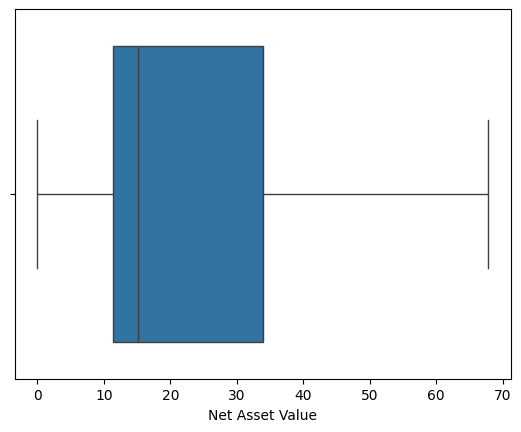

In [39]:
sns.boxplot(x=schemes_copy['Net Asset Value'])

<Axes: xlabel='Net Asset Value', ylabel='Count'>

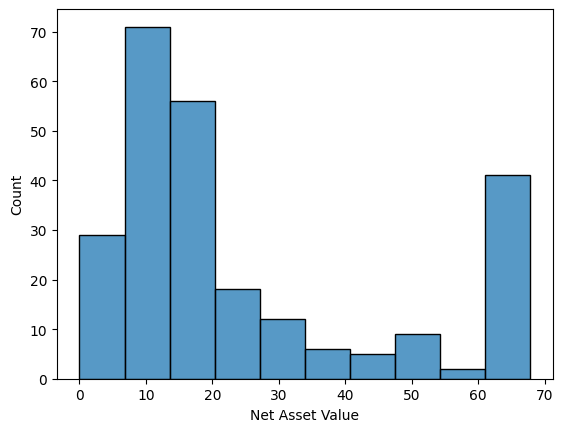

In [40]:
sns.histplot(schemes_copy,x='Net Asset Value')

**main_fund - 5Y**

<Axes: xlabel='5Y'>

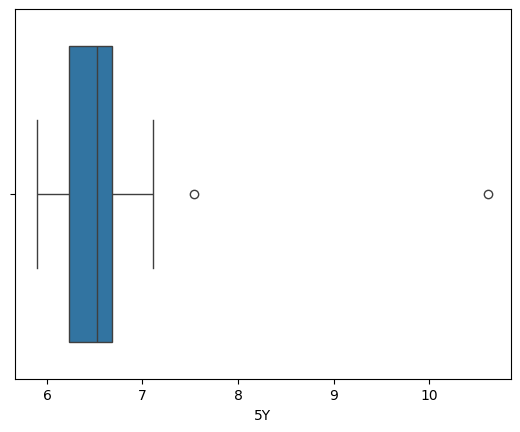

In [41]:
sns.boxplot(main_funds,x='5Y')

In [42]:
from sklearn.ensemble import IsolationForest

numerical_cols_main_funds = main_funds.select_dtypes(include=['number']).columns

iso = IsolationForest(contamination=0.05, random_state=42)
y_pred = iso.fit_predict(main_funds[numerical_cols_main_funds])

outliers_main_funds = main_funds[y_pred == -1]
display(outliers_main_funds)

,Scheme Name,Crisil Rating,AuM (Cr),YTM,1W,1M,3M,6M,YTD,1Y,2Y,3Y,5Y,10Y,Riskometer,Expense Ratio (%),Launch Date
3,Bank of India Short Term Income Fund,2.0,241.11,6.73,0.13,0.57,1.43,3.36,6.93,8.02,9.03,8.100000,10.620,6.23,Moderate,52.0,2013-01-01
7,Edelweiss CRISIL IBX 50:50 Gilt Plus SDL Short...,2.0,147.00,6.26,0.06,0.45,1.03,2.86,6.65,7.64,7.95,8.131739,6.678,7.36,Low to Moderate,20.0,2023-02-15


# **Data Visualization**

**main_funds Dataset**

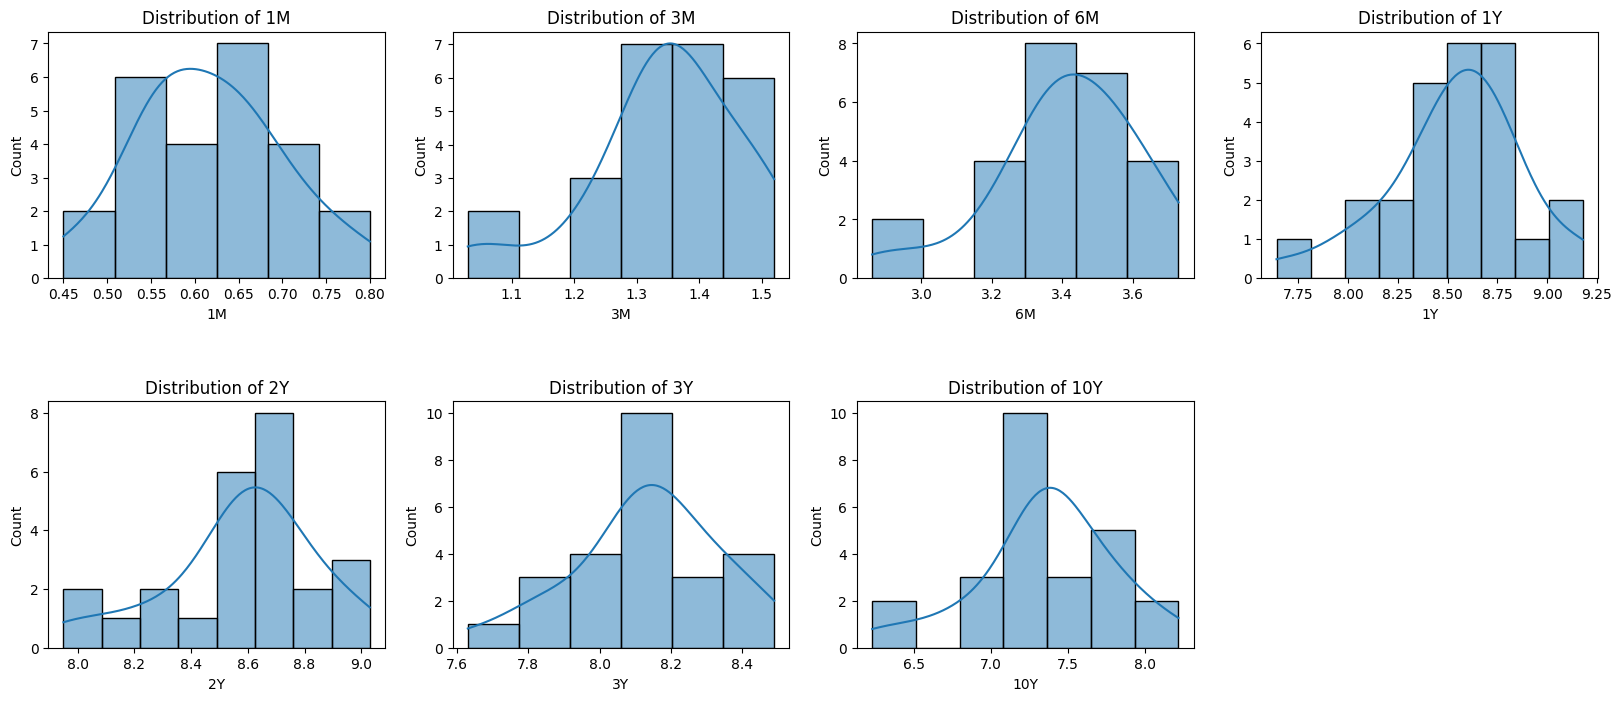

In [43]:
columns = ['1M', '3M', '6M', '1Y', '2Y', '3Y', '10Y']

num_cols = 4
num_rows = (len(columns) + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, col in enumerate(columns):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(main_funds, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.subplots_adjust(hspace=0.5)
plt.show()

Text(0, 0.5, 'Count')

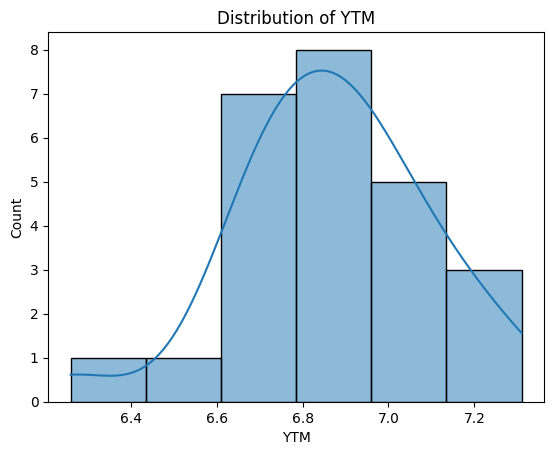

In [44]:
sns.histplot(main_funds, x="YTM", kde=True)
plt.title(f'Distribution of YTM')
plt.xlabel('YTM')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

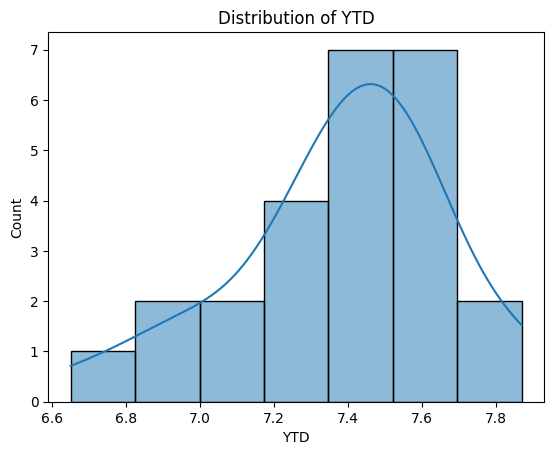

In [45]:
sns.histplot(main_funds, x="YTD", kde=True)
plt.title(f'Distribution of YTD')
plt.xlabel('YTD')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

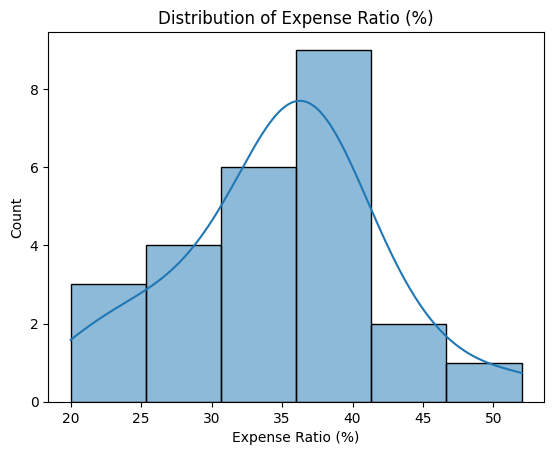

In [46]:
sns.histplot(main_funds, x="Expense Ratio (%)", kde=True)
plt.title(f'Distribution of Expense Ratio (%)')
plt.xlabel('Expense Ratio (%)')
plt.ylabel('Count')

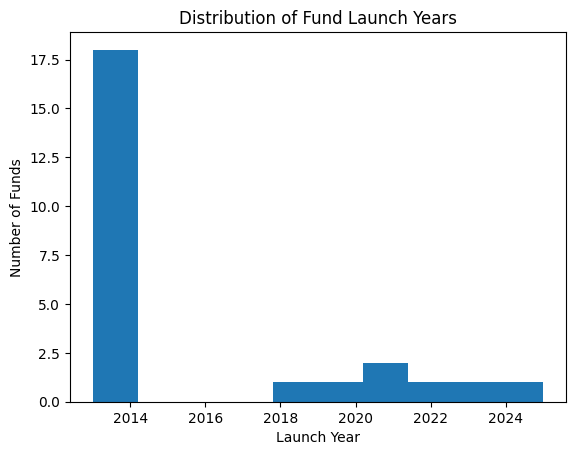

In [47]:
plt.hist(main_funds['Launch Date'].dt.year)
plt.title('Distribution of Fund Launch Years')
plt.xlabel('Launch Year')
plt.ylabel('Number of Funds')
plt.show()

<Axes: xlabel='YTM', ylabel='YTD'>

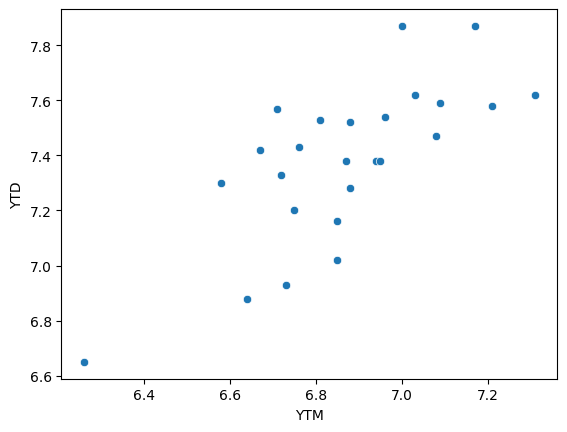

In [48]:
sns.scatterplot(main_funds,x='YTM',y='YTD')

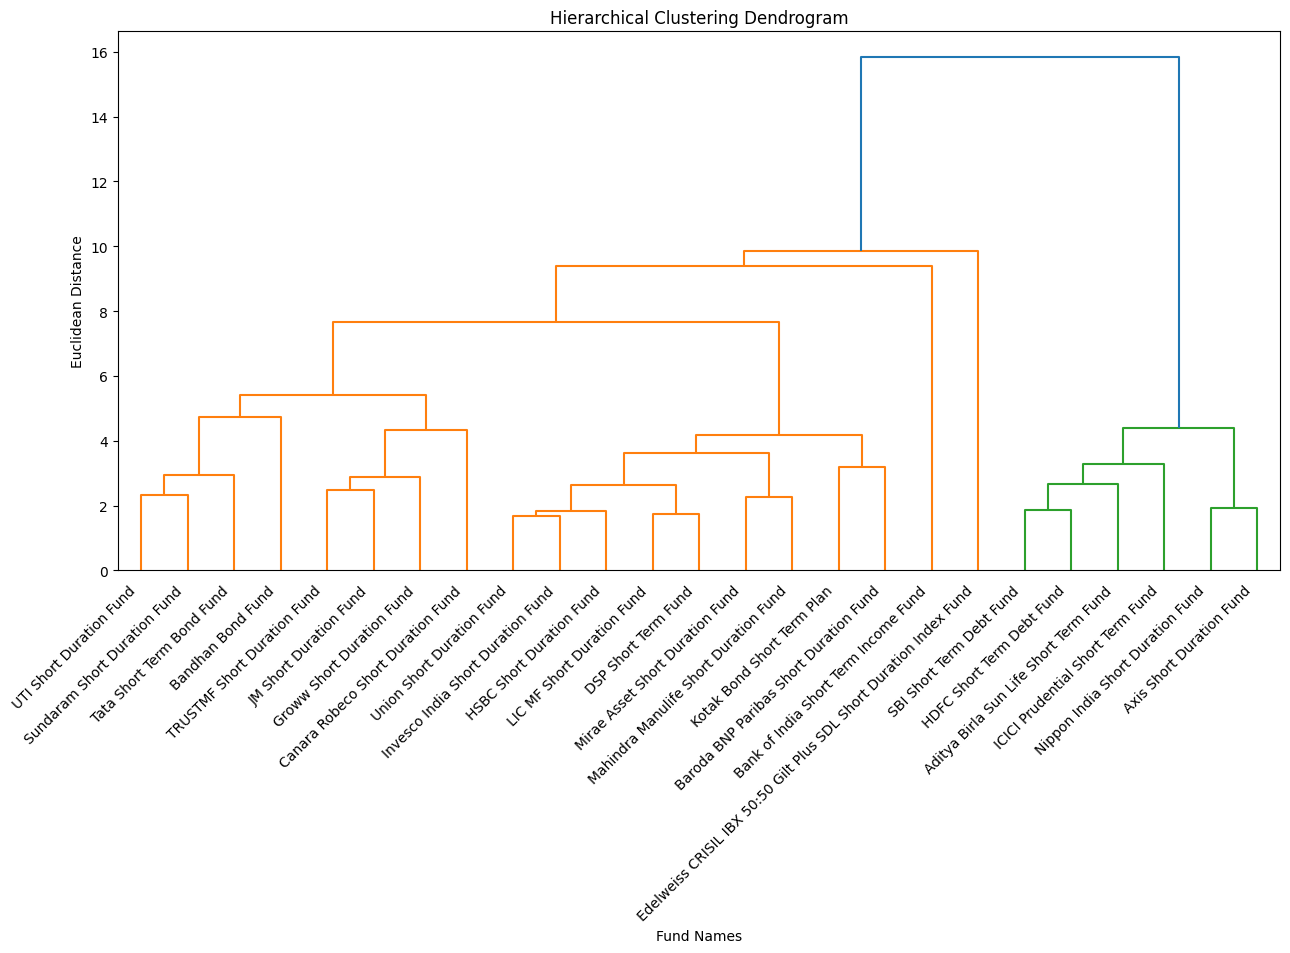

In [49]:
numerical_cols = main_funds.select_dtypes(include=['number']).columns

for col in numerical_cols:
    if main_funds[col].isnull().any():
        main_funds[col].fillna(main_funds[col].mean(), inplace=True)

scaler = StandardScaler()
scaled_data=scaler.fit_transform(main_funds[numerical_cols])

linked = linkage(scaled_data, method='ward')

plt.figure(figsize=(15, 7))

dendrogram(linked, orientation='top', labels=main_funds['Scheme Name'].to_list(), distance_sort='descending',show_leaf_counts=True)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Fund Names')
plt.ylabel('Euclidean Distance')
plt.xticks(rotation=45, ha='right')

plt.show()

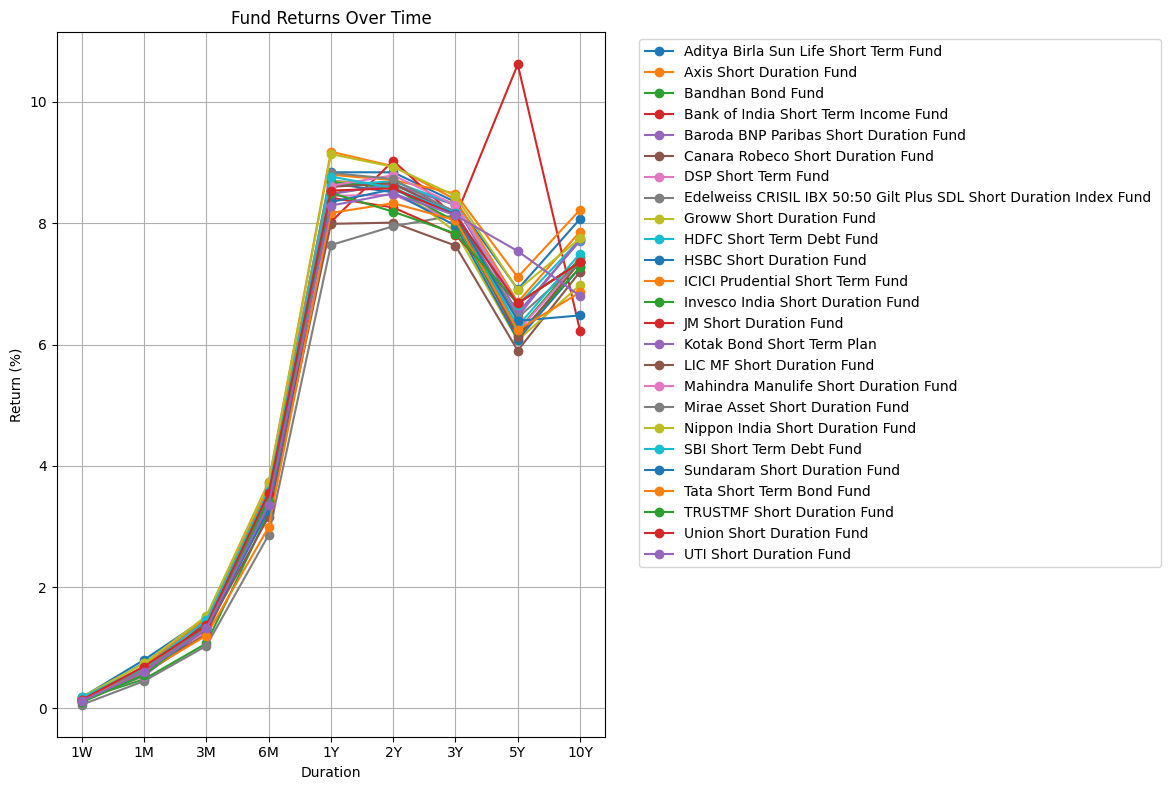

In [50]:
duration_cols = ['1W', '1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '10Y']

plt.figure(figsize=(12, 8))
for i, row in main_funds.iterrows():
    plt.plot(duration_cols, row[duration_cols], marker='o', label=row['Scheme Name'])

plt.xlabel('Duration')
plt.ylabel('Return (%)')
plt.title('Fund Returns Over Time')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside
plt.grid(True)
plt.tight_layout()
plt.show()

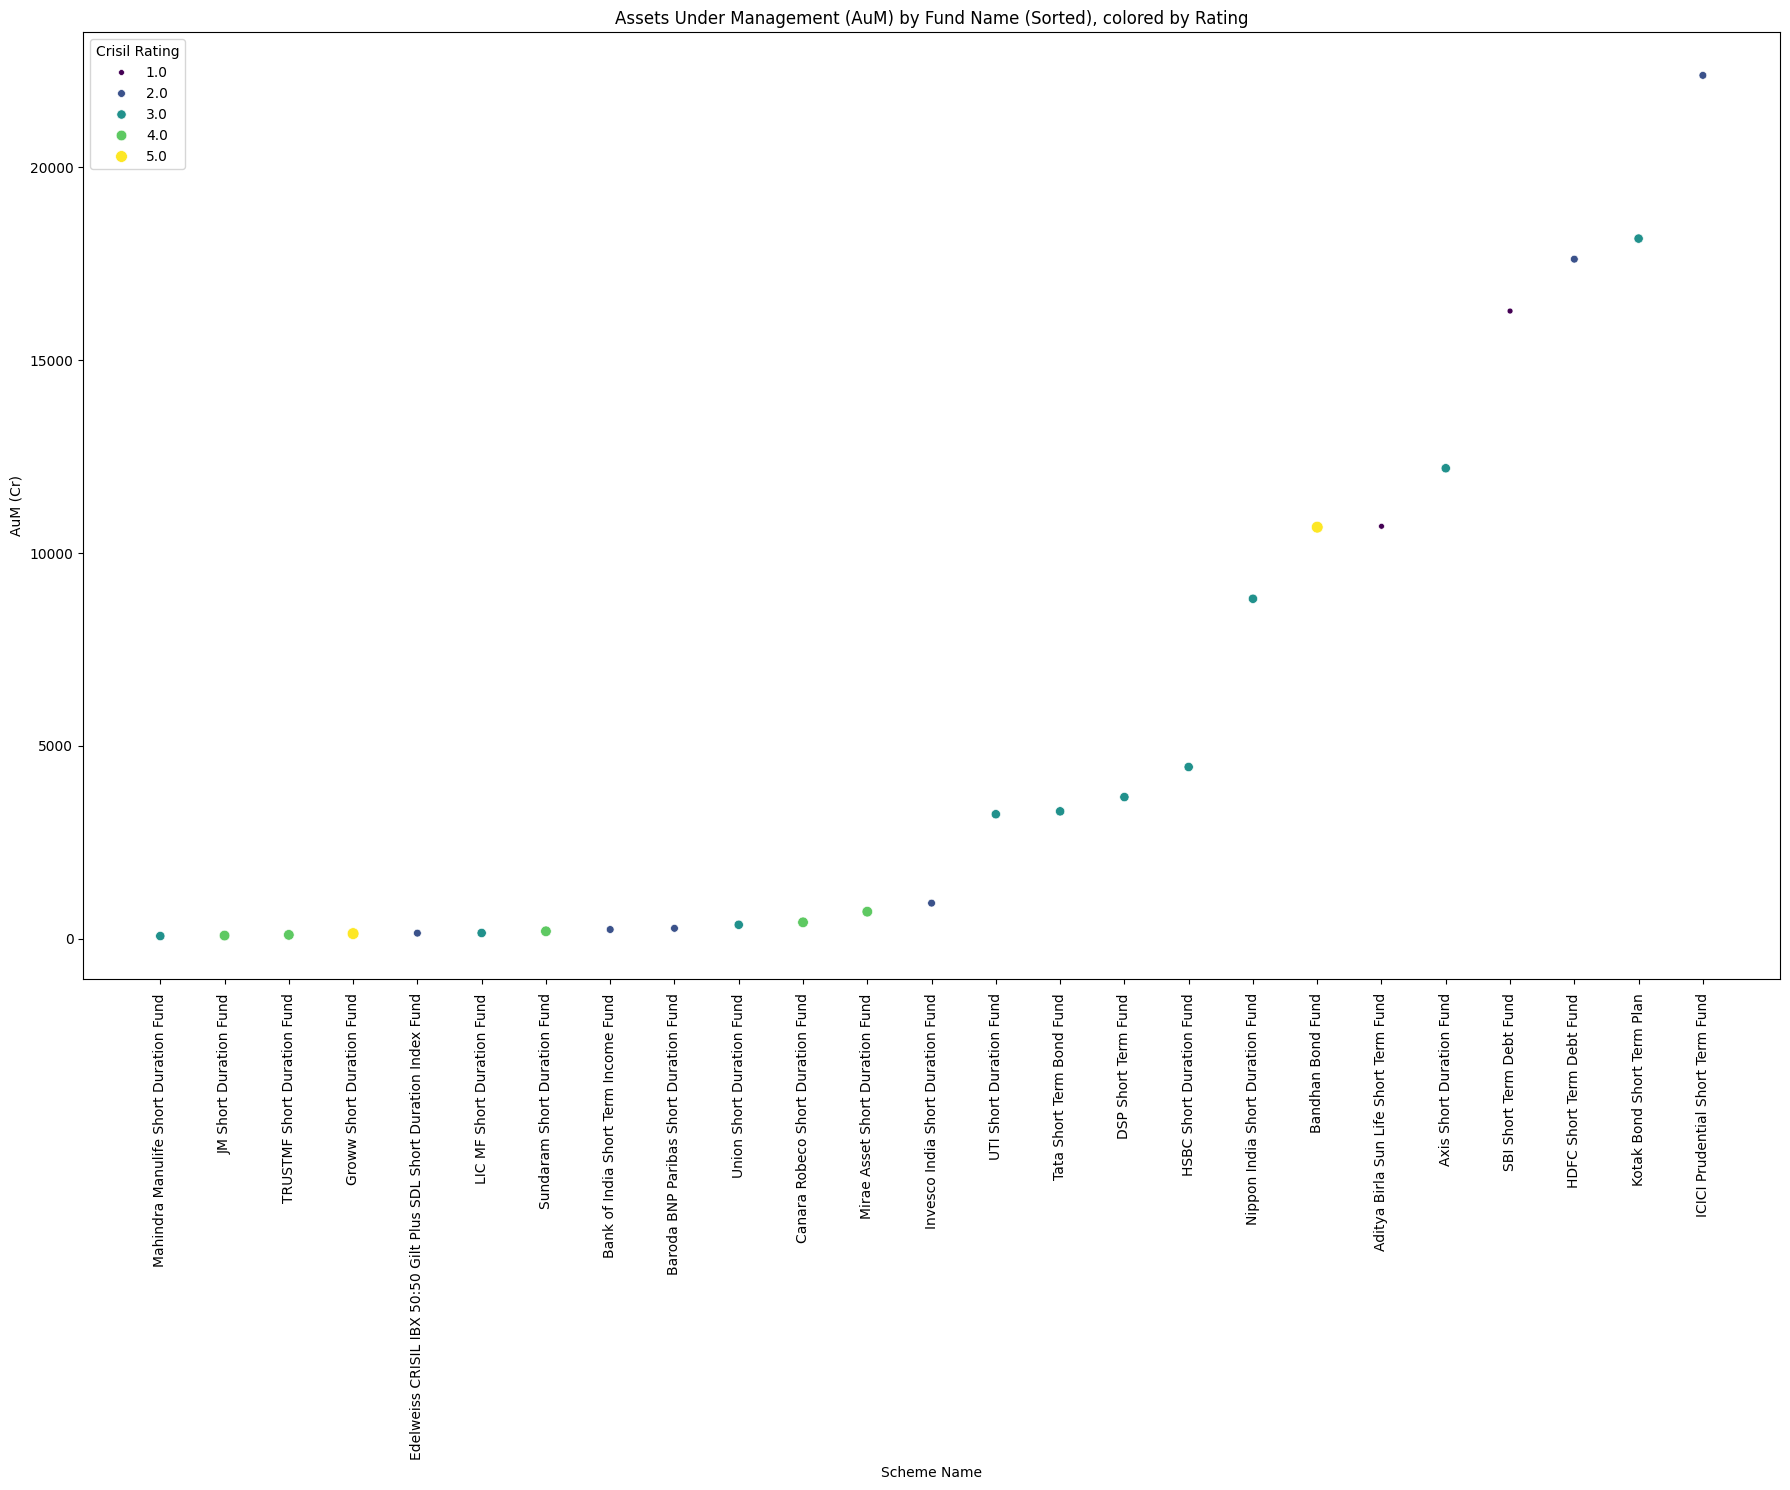

In [51]:
plt.figure(figsize=(18, 15))
main_funds_sorted = main_funds.sort_values(by='AuM (Cr)', ascending=True)
sns.scatterplot(data=main_funds_sorted, x='Scheme Name', y='AuM (Cr)', hue='Crisil Rating',size='Crisil Rating', palette='viridis', s=100)
plt.title('Assets Under Management (AuM) by Fund Name (Sorted), colored by Rating')
plt.xlabel('Scheme Name')
plt.ylabel('AuM (Cr)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Schemes Dataset**

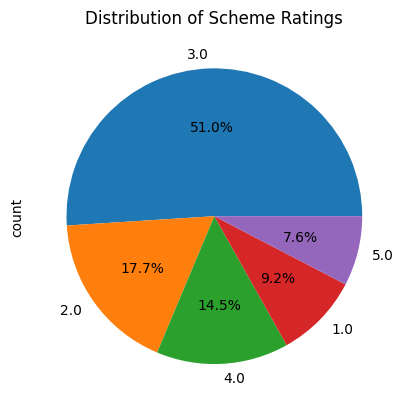

In [52]:
schemes['Rating'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of Scheme Ratings')
plt.show()

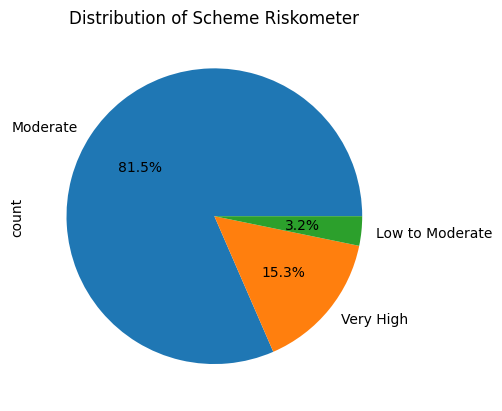

In [53]:
schemes['Riskometer'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of Scheme Riskometer')
plt.show()

Text(0.5, 1.0, 'Distribution of Scheme Ratings')

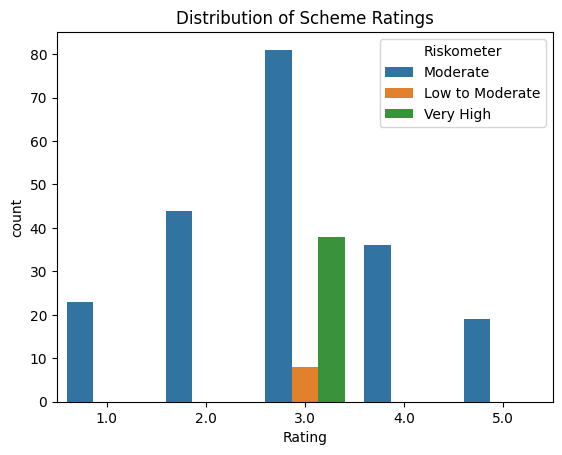

In [54]:
sns.countplot(data=schemes,x='Rating',hue='Riskometer')
plt.title('Distribution of Scheme Ratings')

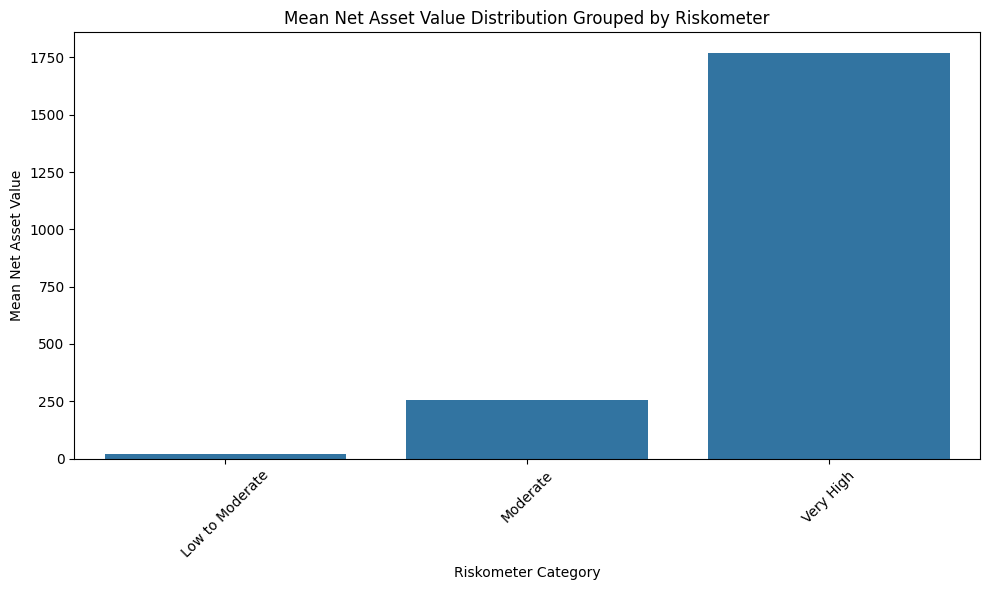

In [55]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=schemes.groupby('Riskometer')['Net Asset Value'].mean().reset_index(),
    x='Riskometer',
    y='Net Asset Value'
)

plt.title("Mean Net Asset Value Distribution Grouped by Riskometer")
plt.xlabel("Riskometer Category")
plt.ylabel("Mean Net Asset Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<Axes: xlabel='Fund Name'>

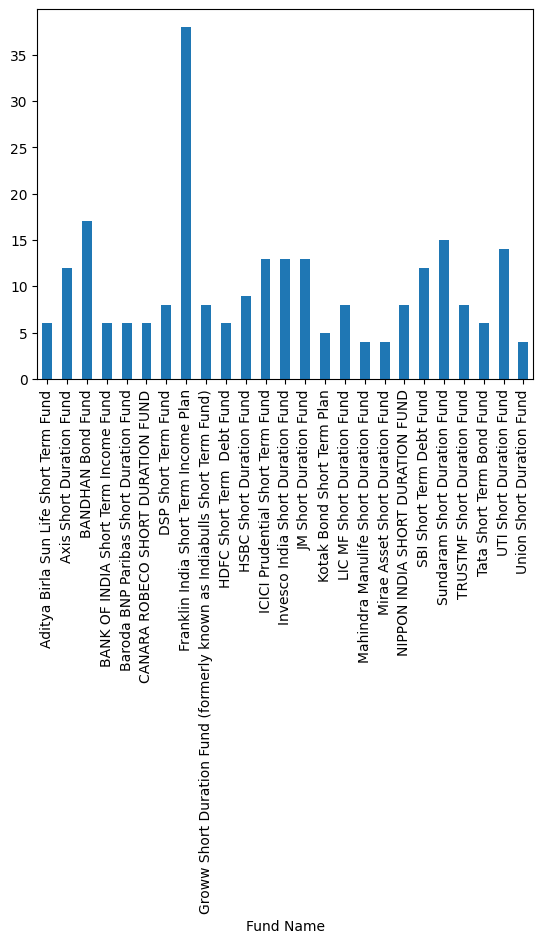

In [56]:
schemes.groupby('Fund Name')['Scheme NAV Name'].count().plot(kind='bar')

**SBI Dataset**

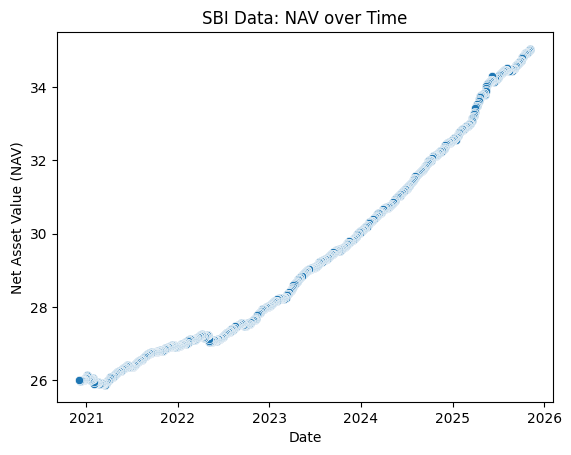

In [57]:
sns.scatterplot(data=sbi_data, x='Date', y='NAV')
plt.title('SBI Data: NAV over Time')
plt.xlabel('Date')
plt.ylabel('Net Asset Value (NAV)')
plt.show()

**Axis Dataset**

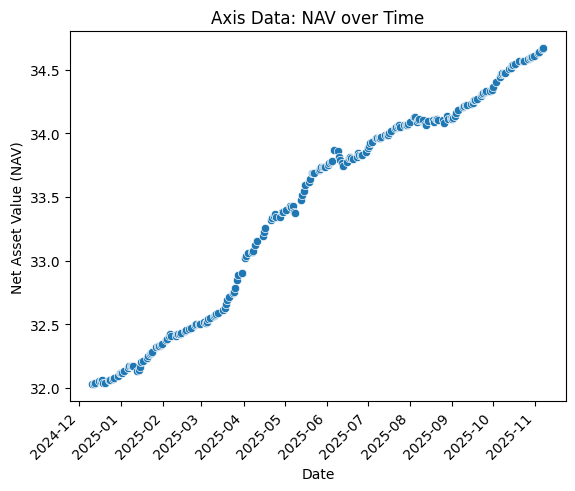

In [58]:
sns.scatterplot(data=axis_data, x='Date', y='Net Asset Value')
plt.title('Axis Data: NAV over Time')
plt.xlabel('Date')
plt.ylabel('Net Asset Value (NAV)')
plt.xticks(rotation=45, ha='right')
plt.show()

**HDFC Dataset**

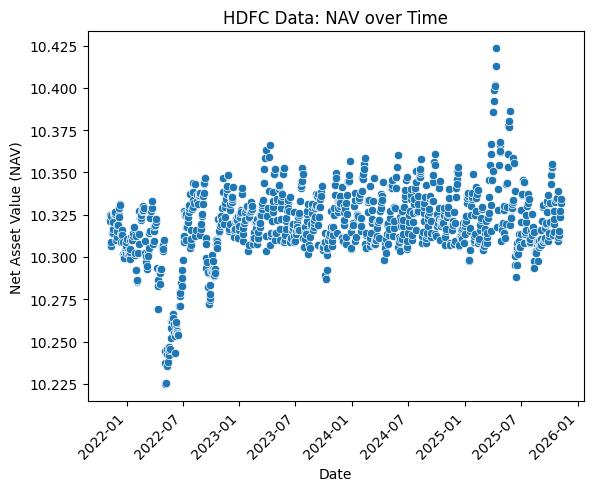

In [59]:
sns.scatterplot(data=hdfc_data, x='Date', y='Net Asset Value')
plt.title('HDFC Data: NAV over Time')
plt.xlabel('Date')
plt.ylabel('Net Asset Value (NAV)')
plt.xticks(rotation=45, ha='right')
plt.show()

# **Model Training**

**Model trained for Riskometer Prediction**

In [60]:
X=schemes[["Net Asset Value","Rating"]]
Y = schemes["Riskometer"]

In [61]:
model_train = DecisionTreeClassifier(random_state=42)

In [62]:
param_grid = {
    'max_depth': range(1,50),
}

grid_search = GridSearchCV(
    estimator=model_train,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
)

grid_search.fit(X, Y)

print("Best F1 weighted score:", grid_search.best_score_)
print("Best Tree Settings:", grid_search.best_params_)

Best F1 weighted score: 0.9168576823033383
Best Tree Settings: {'max_depth': 5}


Knee Point at max_depth=5

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (199, 2)
Testing data shape: (50, 2)


In [64]:
model = DecisionTreeClassifier(max_depth=5,random_state=42)

In [65]:
model.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


In [66]:
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("Predictions made.")
for i in range(5):
    print(f"Predicted: {y_pred[i]}, Actual: {y_test.iloc[i]}")

Accuracy: 0.92
Predictions made.
Predicted: Very High, Actual: Moderate
Predicted: Moderate, Actual: Moderate
Predicted: Very High, Actual: Very High
Predicted: Moderate, Actual: Low to Moderate
Predicted: Moderate, Actual: Moderate


**Model trained for Net Asset Value for Axis dataset**

In [67]:
X_axis = axis_data['Date'].map(dt.datetime.toordinal).to_frame()
Y_axis = axis_data["Net Asset Value"]

In [68]:
model_linear = LinearRegression()

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model_linear, X_axis, Y_axis, cv=cv_strategy, scoring='r2')

print("Linear Regression Scores:", scores)
print("Average R2:", scores.mean())

Linear Regression Scores: [0.95863625 0.96020867 0.97666346 0.97211677 0.95908143]
Average R2: 0.9653413157228394


In [69]:
model_linear = LinearRegression()
X_train, X_test, y_train, y_test = train_test_split(X_axis,Y_axis, test_size=0.2, random_state=42)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (178, 1)
Testing data shape: (45, 1)


In [70]:
model_linear.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


In [71]:
y_pred = model_linear.predict(X_test)
print("Predictions made.")
for i in range(5):
    print(f"Predicted: {y_pred[i]}, Actual: {y_test.iloc[i]}")

Predictions made.
Predicted: 32.10838723784491, Actual: 32.0657
Predicted: 33.087559444138606, Actual: 33.2579
Predicted: 33.50843170824737, Actual: 33.7837
Predicted: 33.843411673558876, Actual: 33.9841
Predicted: 34.81399464997321, Actual: 34.6427


**Model trained for Net Asset Value for SBI dataset**

In [72]:
X_sbi = sbi_data['Date'].map(dt.datetime.toordinal).to_frame()
Y_sbi = sbi_data["NAV"]

In [73]:
model_sbi = LinearRegression()

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model_sbi, X_sbi, Y_sbi, cv=cv_strategy, scoring='r2')

print("Linear Regression Scores:", scores)
print("Average R2:", scores.mean())

Linear Regression Scores: [0.95922128 0.95565882 0.95547716 0.95907421 0.95653469]
Average R2: 0.9571932324220362


In [74]:
model_sbi = LinearRegression()
X_train, X_test, y_train, y_test = train_test_split(X_sbi,Y_sbi, test_size=0.2, random_state=42)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (948, 1)
Testing data shape: (238, 1)


In [75]:
model_sbi.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


In [76]:
y_pred = model_sbi.predict(X_test)
print("Predictions made.")
for i in range(5):
    print(f"Predicted: {y_pred[i]}, Actual: {y_test.iloc[i]}")

Predictions made.
Predicted: 31.632264944509643, Actual: 31.4099
Predicted: 26.614327447664436, Actual: 26.8943
Predicted: 24.849326937526257, Actual: 25.9977
Predicted: 33.39726545464782, Actual: 34.2973
Predicted: 26.347525044968734, Actual: 26.764
